In [1]:
import cartopy.crs as ccrs
import dask.dataframe as dd
import matplotlib.animation as animation
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from tqdm.auto import tqdm

from pipelines.contrails_org_iagos import open_adsb, open_forecast, apply_horizontal_buffer
from pipelines.contrails_org_iagos import open_observations as open_iagos
from pipelines.contrails_org_contrailwatch import open_observations as open_contrailwatch

In [2]:
exo_black = "#161a26"
tropo_blue = "#1093ff"
solar_orange = "#f26400"
gray50 = "#939598"

In [3]:
N = 256
vals = np.ones((N, 4))
r, g, b = colors.to_rgb(exo_black)
vals[:, 0] = np.linspace(r, 1, N)
vals[:, 1] = np.linspace(g, 1, N)
vals[:, 2] = np.linspace(b, 1, N)
greys = colors.ListedColormap(vals)
greys_r = colors.ListedColormap(vals[::-1, :])

In [4]:
hit_color = tropo_blue
miss_color = solar_orange
avoid_color = "salmon"
ok_color = "mediumseagreen"

# Contrails.org forecast vs GOES

## Hit rate (unbuffered)

In [5]:
time = pd.Timestamp("2024-12-02 16:00")
flight_level = 350

In [6]:
forecast = open_forecast(time, flight_level)
adsb = open_adsb(time, flight_level)
observed = open_contrailwatch(time, flight_level)

In [7]:
target_lon = xr.DataArray(observed["longitude"], dims="observed")
target_lat = xr.DataArray(observed["latitude"], dims="observed")
hit = forecast["pcr"].squeeze().sel(longitude=target_lon, latitude=target_lat).values

  0%|          | 0/744 [00:00<?, ?it/s]

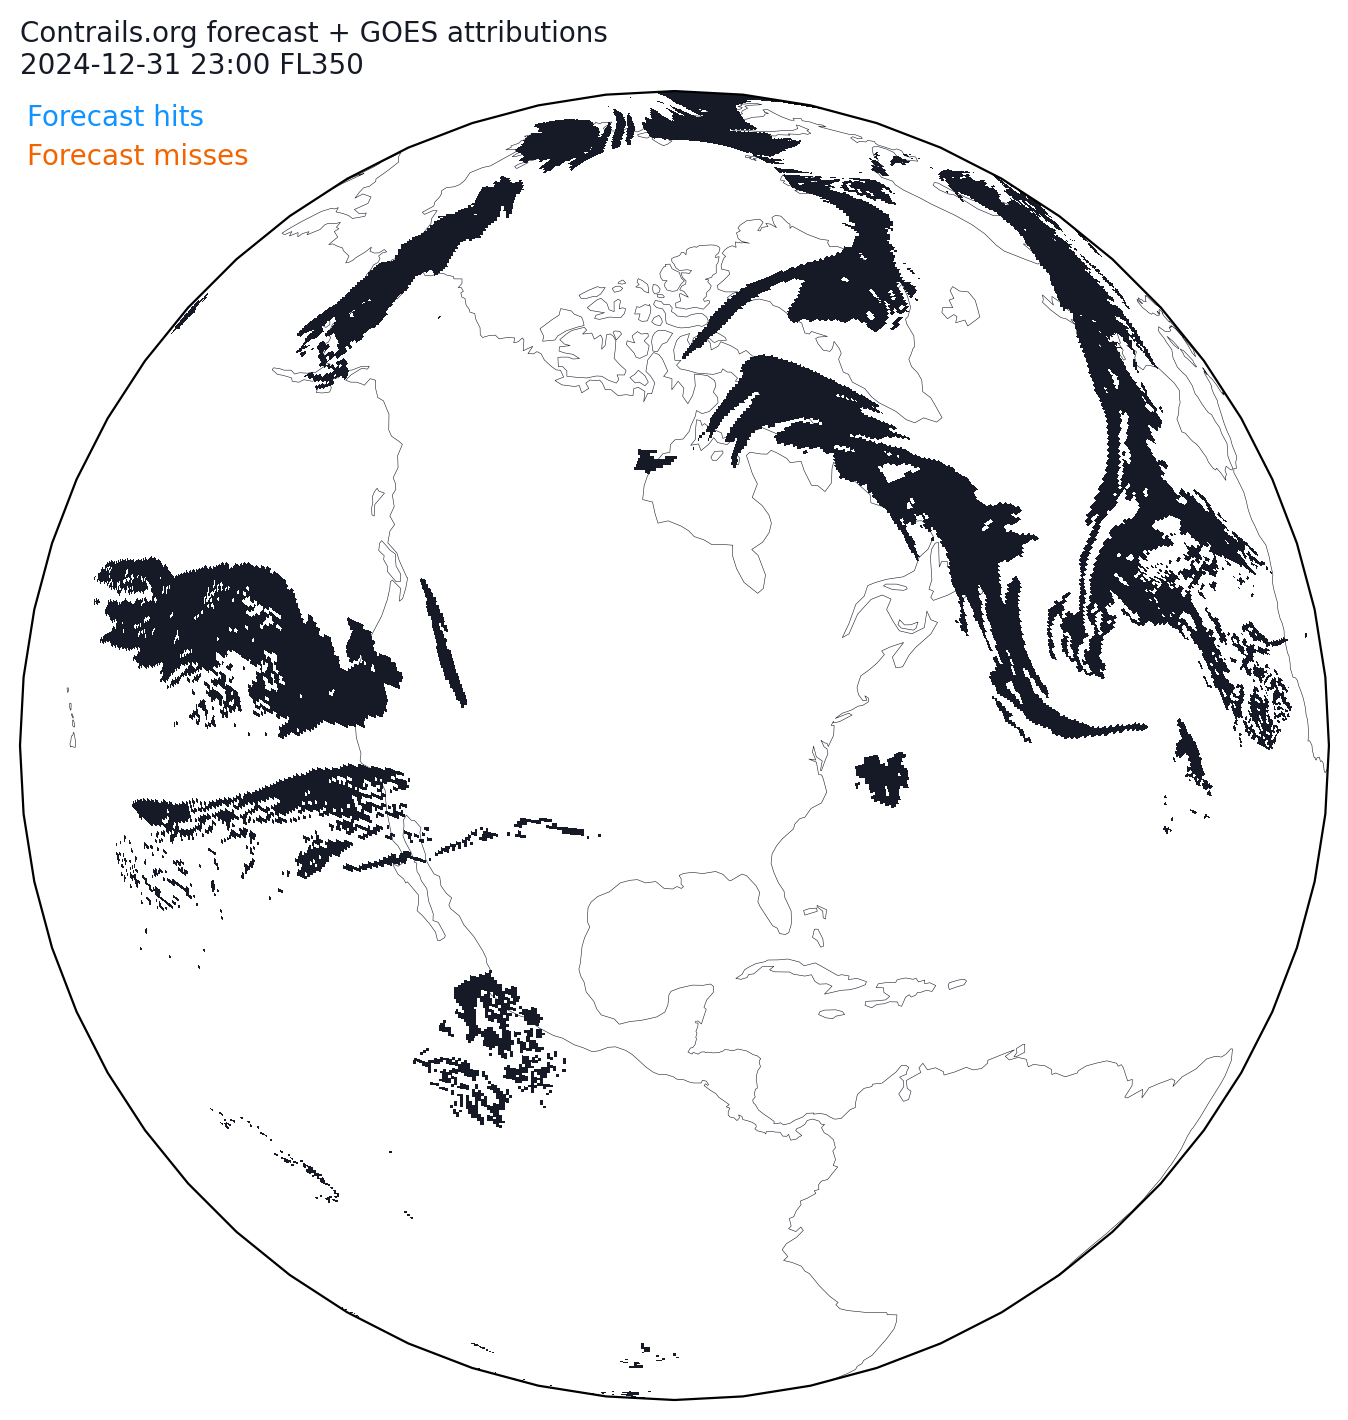

In [8]:
fig = plt.figure(figsize=(7.2, 7.2), dpi=200)
ax = plt.subplot(111, projection=ccrs.NearsidePerspective(central_longitude=-90, central_latitude=40))

regions = ax.pcolormesh(forecast["longitude"], forecast["latitude"], forecast["pcr"].squeeze().T, cmap=greys_r, shading="nearest", transform=ccrs.PlateCarree())
hits, = ax.plot(observed[hit]["longitude"], observed[hit]["latitude"], ".", color=hit_color, mew=0, ms=4, transform=ccrs.PlateCarree())
misses, = ax.plot(observed[~hit]["longitude"], observed[~hit]["latitude"], ".", color=miss_color, mew=0, ms=4, transform=ccrs.PlateCarree())
ax.coastlines(lw=0.2, color=exo_black)

ax.annotate("Forecast hits", xy=(0.005, 0.99), xycoords="axes fraction", color=hit_color, ha="left", va="top")
ax.annotate("Forecast misses", xy=(0.005, 0.96), xycoords="axes fraction", color=miss_color, ha="left", va="top")
title = ax.set_title(
    f"Contrails.org forecast + GOES attributions\n{time.strftime('%Y-%m-%d %H:%M')} FL{flight_level}",
    fontsize=10, color=exo_black, loc="left"
)
fig.tight_layout()

def update(time: pd.Timestamp):
    
    forecast = open_forecast(time, flight_level)
    observed = open_contrailwatch(time, flight_level)

    target_lon = xr.DataArray(observed["longitude"], dims="observed")
    target_lat = xr.DataArray(observed["latitude"], dims="observed")
    hit = forecast["pcr"].squeeze().sel(longitude=target_lon, latitude=target_lat).values

    regions.set_array(forecast["pcr"].squeeze().T)
    hits.set_data(observed[hit]["longitude"], observed[hit]["latitude"])
    misses.set_data(observed[~hit]["longitude"], observed[~hit]["latitude"])
    title.set_text(f"Contrails.org forecast + GOES attributions\n{time.strftime('%Y-%m-%d %H:%M')} FL{flight_level}")

    return [regions, hits, misses, title]

frames = tqdm(pd.date_range("2024-12-01 00:00", "2024-12-31 23:00", freq="1h"))

anim = animation.FuncAnimation(fig, update, frames=frames, blit=True, cache_frame_data=False)
anim.save("contrails_org_goes_nh.mp4", writer="ffmpeg", fps=12, extra_args=['-vcodec', 'libx264', '-pix_fmt', 'yuv420p', '-crf', '23'])

## Flight distance (unbuffered)

In [9]:
target_lon = xr.DataArray(adsb["longitude"], dims="adsb")
target_lat = xr.DataArray(adsb["latitude"], dims="adsb")
hit = forecast["pcr"].squeeze().sel(longitude=target_lon, latitude=target_lat).values

  0%|          | 0/744 [00:00<?, ?it/s]

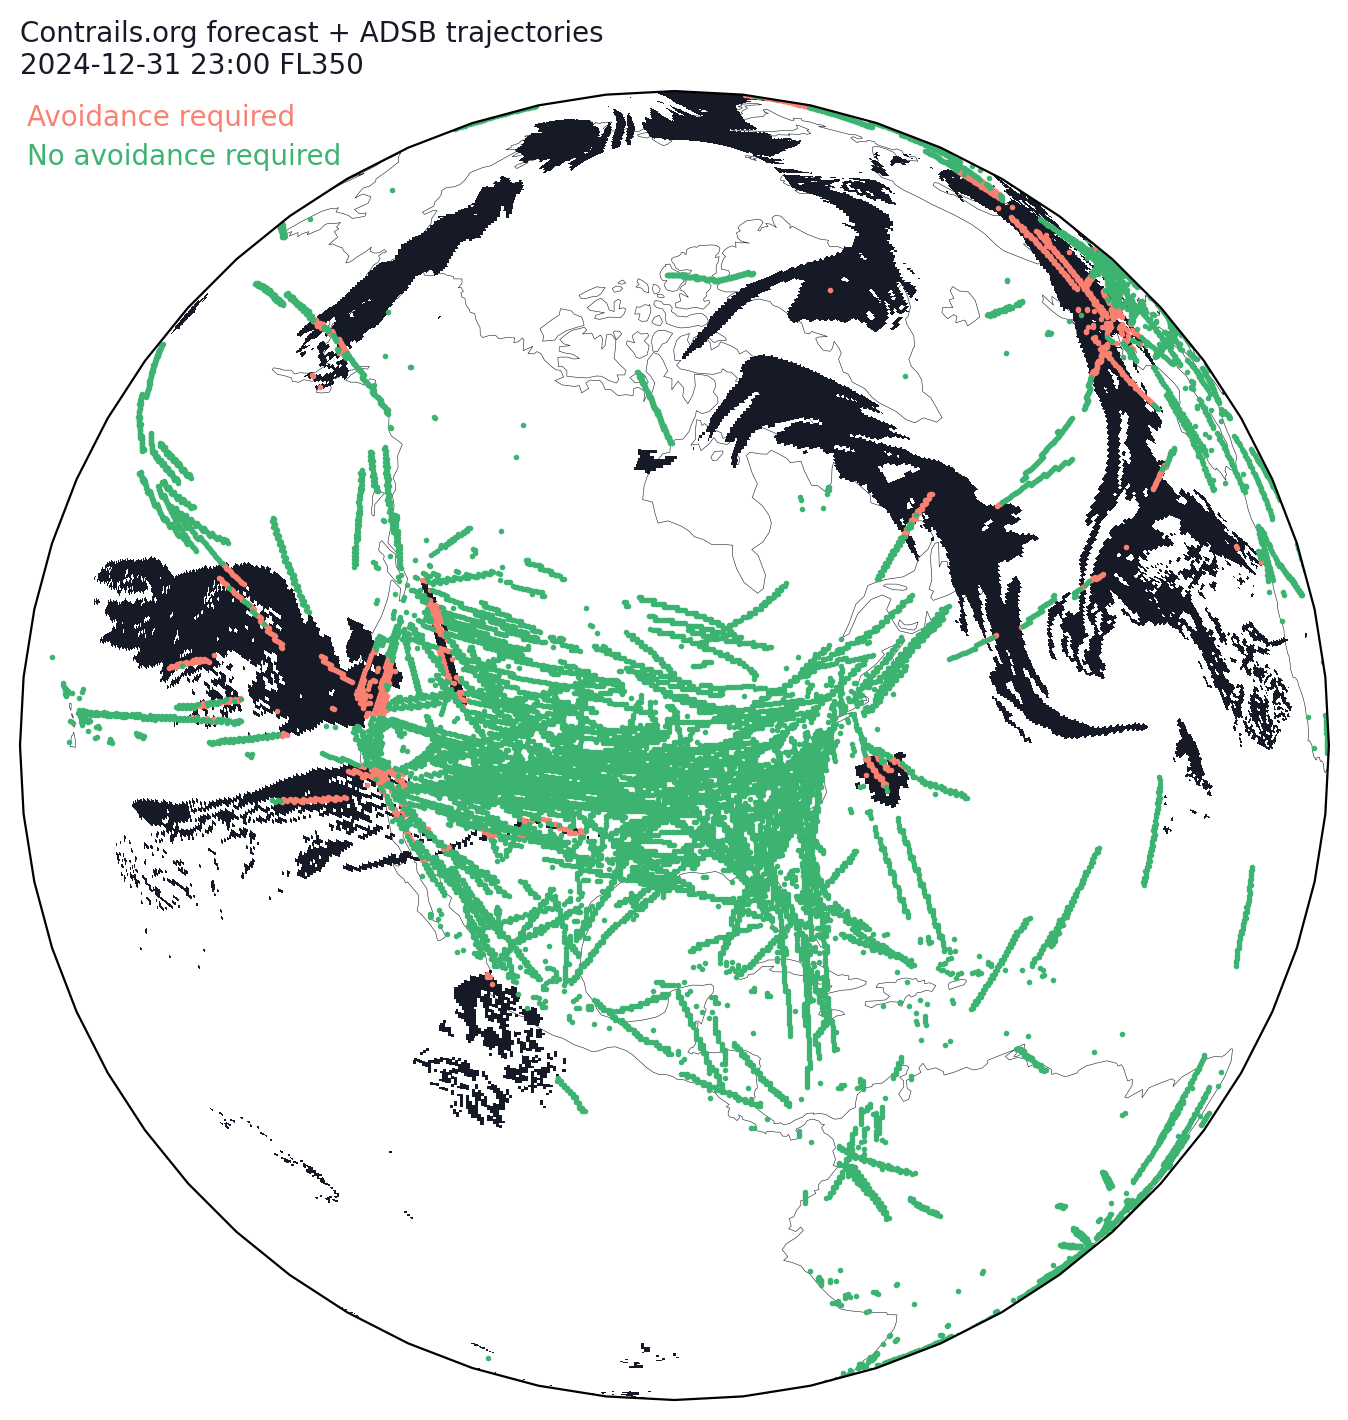

In [10]:
fig = plt.figure(figsize=(7.2, 7.2), dpi=200)
ax = plt.subplot(111, projection=ccrs.NearsidePerspective(central_longitude=-90, central_latitude=40))

regions = ax.pcolormesh(forecast["longitude"], forecast["latitude"], forecast["pcr"].squeeze().T, cmap=greys_r, shading="nearest", transform=ccrs.PlateCarree())
hits, = ax.plot(adsb[hit]["longitude"], adsb[hit]["latitude"], ".", color=avoid_color, mew=0, ms=4, transform=ccrs.PlateCarree())
misses, = ax.plot(adsb[~hit]["longitude"], adsb[~hit]["latitude"], ".", color=ok_color, mew=0, ms=4, transform=ccrs.PlateCarree())
ax.coastlines(lw=0.2, color=exo_black)

ax.annotate("Avoidance required", xy=(0.005, 0.99), xycoords="axes fraction", color=avoid_color, ha="left", va="top")
ax.annotate("No avoidance required", xy=(0.005, 0.96), xycoords="axes fraction", color=ok_color, ha="left", va="top")
title = ax.set_title(
    f"Contrails.org forecast + ADSB trajectories\n{time.strftime('%Y-%m-%d %H:%M')} FL{flight_level}",
    fontsize=10, color=exo_black, loc="left"
)
fig.tight_layout()

def update(time: pd.Timestamp):
    
    forecast = open_forecast(time, flight_level)
    adsb = open_adsb(time, flight_level)

    target_lon = xr.DataArray(adsb["longitude"], dims="observed")
    target_lat = xr.DataArray(adsb["latitude"], dims="observed")
    hit = forecast["pcr"].squeeze().sel(longitude=target_lon, latitude=target_lat).values

    regions.set_array(forecast["pcr"].squeeze().T)
    hits.set_data(adsb[hit]["longitude"], adsb[hit]["latitude"])
    misses.set_data(adsb[~hit]["longitude"], adsb[~hit]["latitude"])
    title.set_text(f"Contrails.org forecast + ADSB trajectories\n{time.strftime('%Y-%m-%d %H:%M')} FL{flight_level}")

    return [regions, hits, misses, title]

frames = tqdm(pd.date_range("2024-12-01 00:00", "2024-12-31 23:00", freq="1h"))

anim = animation.FuncAnimation(fig, update, frames=frames, blit=True, cache_frame_data=False)
anim.save("contrails_org_adsb_nh.mp4", writer="ffmpeg", fps=12, extra_args=['-vcodec', 'libx264', '-pix_fmt', 'yuv420p', '-crf', '23'])

## Hit rate (buffered)

In [11]:
buffered = apply_horizontal_buffer(forecast["pcr"], 10)

In [12]:
target_lon = xr.DataArray(observed["longitude"], dims="observed")
target_lat = xr.DataArray(observed["latitude"], dims="observed")
hit = buffered.squeeze().sel(longitude=target_lon, latitude=target_lat).values

  0%|          | 0/744 [00:00<?, ?it/s]

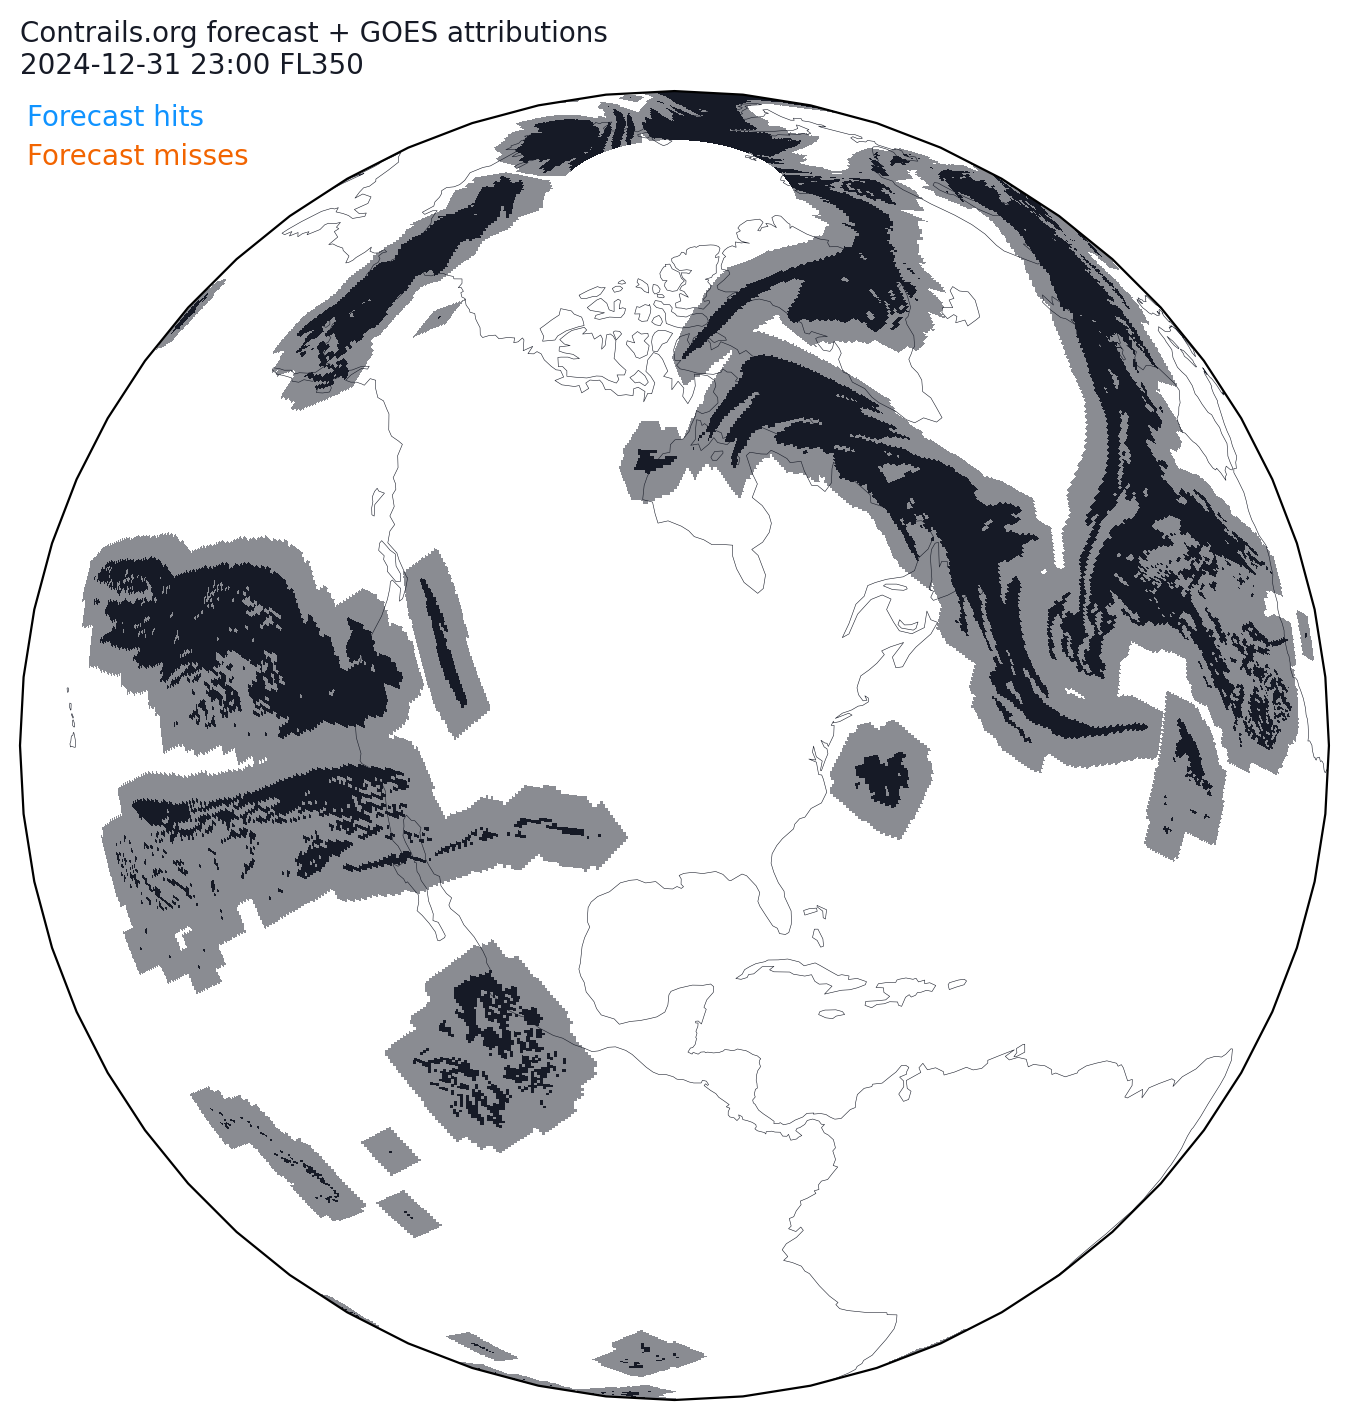

In [13]:
fig = plt.figure(figsize=(7.2, 7.2), dpi=200)
ax = plt.subplot(111, projection=ccrs.NearsidePerspective(central_longitude=-90, central_latitude=40))

regions = ax.pcolormesh(
    forecast["longitude"],
    forecast["latitude"],
    (forecast["pcr"].astype(int) + buffered.astype(int)).squeeze().T,
    cmap=greys_r, shading="nearest", transform=ccrs.PlateCarree()
)
hits, = ax.plot(observed[hit]["longitude"], observed[hit]["latitude"], ".", color=hit_color, mew=0, ms=4, transform=ccrs.PlateCarree())
misses, = ax.plot(observed[~hit]["longitude"], observed[~hit]["latitude"], ".", color=miss_color, mew=0, ms=4, transform=ccrs.PlateCarree())
ax.coastlines(lw=0.2, color=exo_black)

ax.annotate("Forecast hits", xy=(0.005, 0.99), xycoords="axes fraction", color=hit_color, ha="left", va="top")
ax.annotate("Forecast misses", xy=(0.005, 0.96), xycoords="axes fraction", color=miss_color, ha="left", va="top")
title = ax.set_title(
    f"Contrails.org forecast + GOES attributions\n{time.strftime('%Y-%m-%d %H:%M')} FL{flight_level}",
    fontsize=10, color=exo_black, loc="left"
)
fig.tight_layout()

def update(time: pd.Timestamp):
    
    forecast = open_forecast(time, flight_level)
    observed = open_contrailwatch(time, flight_level)
    buffered = apply_horizontal_buffer(forecast["pcr"], 10)

    target_lon = xr.DataArray(observed["longitude"], dims="observed")
    target_lat = xr.DataArray(observed["latitude"], dims="observed")
    hit = buffered.squeeze().sel(longitude=target_lon, latitude=target_lat).values

    regions.set_array((forecast["pcr"].astype(int) + buffered.astype(int)).squeeze().T)
    hits.set_data(observed[hit]["longitude"], observed[hit]["latitude"])
    misses.set_data(observed[~hit]["longitude"], observed[~hit]["latitude"])
    title.set_text(f"Contrails.org forecast + GOES attributions\n{time.strftime('%Y-%m-%d %H:%M')} FL{flight_level}")

    return [regions, hits, misses, title]

frames = tqdm(pd.date_range("2024-12-01 00:00", "2024-12-31 23:00", freq="1h"))

anim = animation.FuncAnimation(fig, update, frames=frames, blit=True, cache_frame_data=False)
anim.save("contrails_org_buffered_goes_nh.mp4", writer="ffmpeg", fps=12, extra_args=['-vcodec', 'libx264', '-pix_fmt', 'yuv420p', '-crf', '23'])

## Flight distance (buffered)

In [14]:
target_lon = xr.DataArray(adsb["longitude"], dims="adsb")
target_lat = xr.DataArray(adsb["latitude"], dims="adsb")
hit = buffered.squeeze().sel(longitude=target_lon, latitude=target_lat).values

  0%|          | 0/744 [00:00<?, ?it/s]

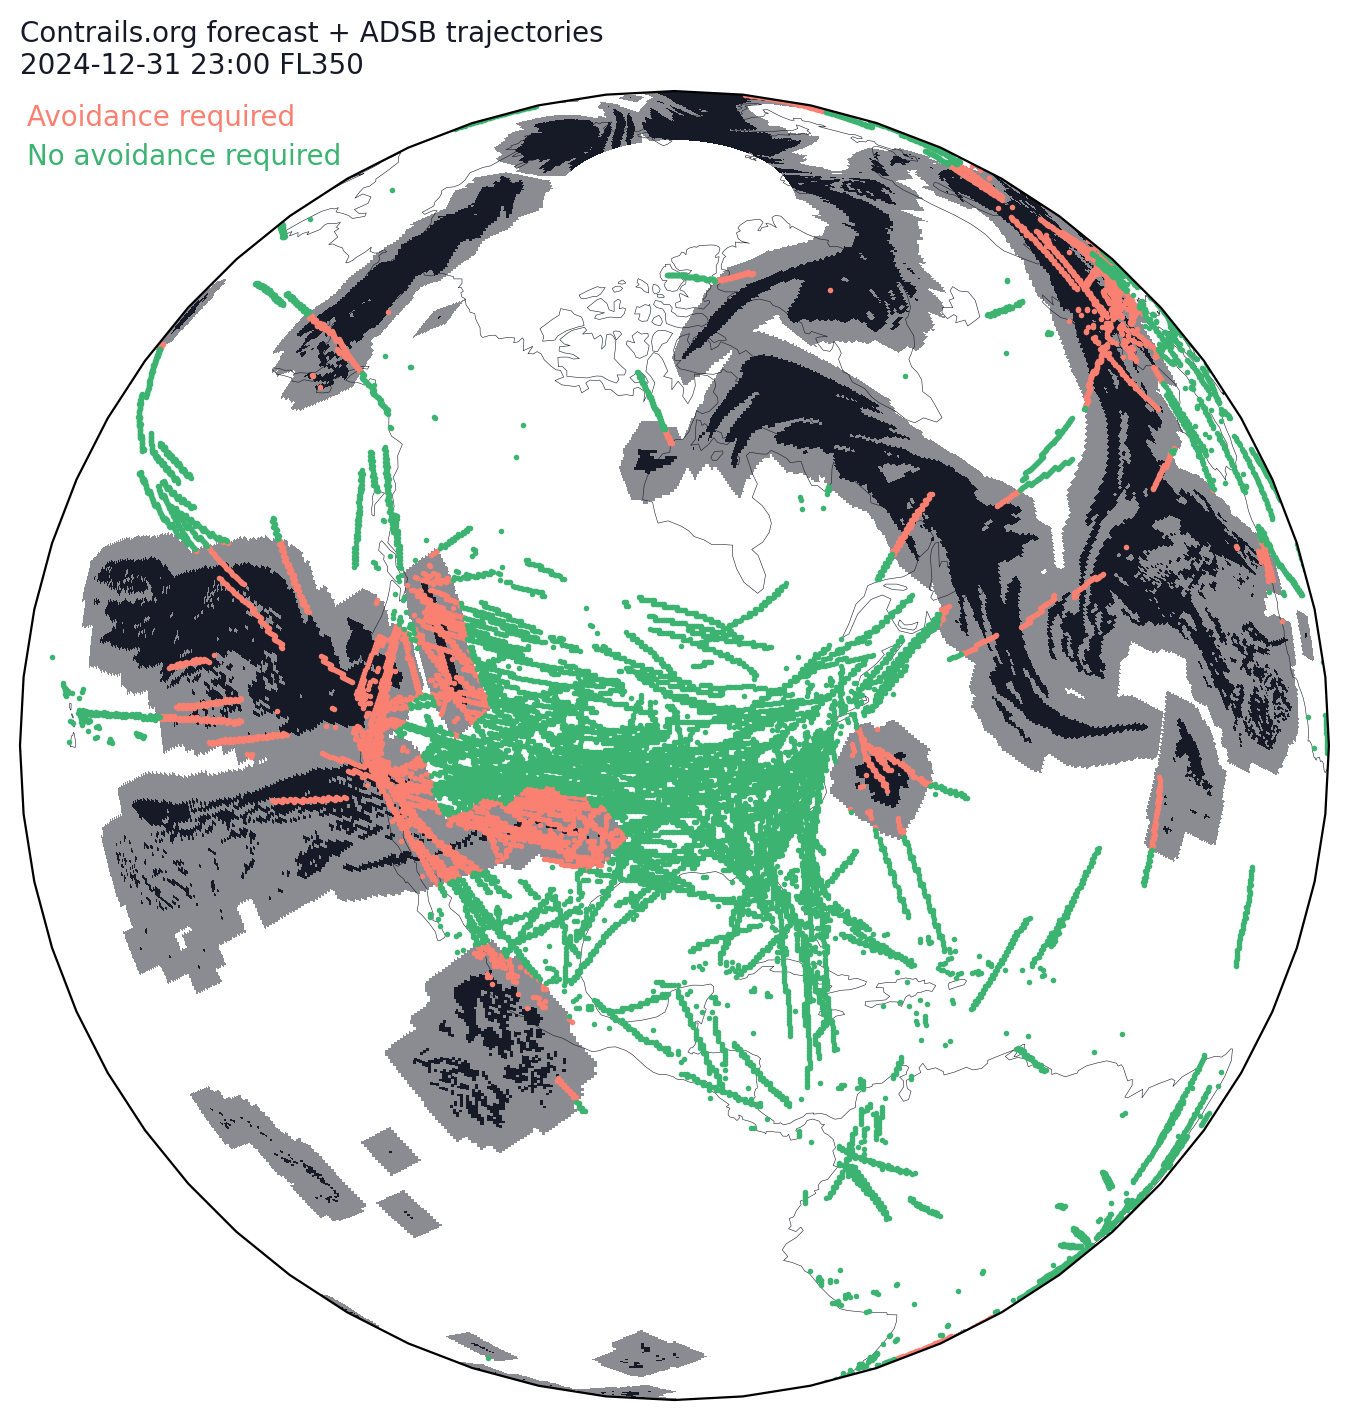

In [15]:
fig = plt.figure(figsize=(7.2, 7.2), dpi=200)
ax = plt.subplot(111, projection=ccrs.NearsidePerspective(central_longitude=-90, central_latitude=40))

regions = ax.pcolormesh(
    forecast["longitude"],
    forecast["latitude"],
    (forecast["pcr"].astype(int) + buffered.astype(int)).squeeze().T,
    cmap=greys_r, shading="nearest", transform=ccrs.PlateCarree()
)
hits, = ax.plot(adsb[hit]["longitude"], adsb[hit]["latitude"], ".", color=avoid_color, mew=0, ms=4, transform=ccrs.PlateCarree())
misses, = ax.plot(adsb[~hit]["longitude"], adsb[~hit]["latitude"], ".", color=ok_color, mew=0, ms=4, transform=ccrs.PlateCarree())
ax.coastlines(lw=0.2, color=exo_black)

ax.annotate("Avoidance required", xy=(0.005, 0.99), xycoords="axes fraction", color=avoid_color, ha="left", va="top")
ax.annotate("No avoidance required", xy=(0.005, 0.96), xycoords="axes fraction", color=ok_color, ha="left", va="top")
title = ax.set_title(
    f"Contrails.org forecast + ADSB trajectories\n{time.strftime('%Y-%m-%d %H:%M')} FL{flight_level}",
    fontsize=10, color=exo_black, loc="left"
)
fig.tight_layout()

def update(time: pd.Timestamp):
    
    forecast = open_forecast(time, flight_level)
    adsb = open_adsb(time, flight_level)
    buffered = apply_horizontal_buffer(forecast["pcr"], 10)

    target_lon = xr.DataArray(adsb["longitude"], dims="observed")
    target_lat = xr.DataArray(adsb["latitude"], dims="observed")
    hit = buffered.squeeze().sel(longitude=target_lon, latitude=target_lat).values

    regions.set_array((forecast["pcr"].astype(int) + buffered.astype(int)).squeeze().T)
    hits.set_data(adsb[hit]["longitude"], adsb[hit]["latitude"])
    misses.set_data(adsb[~hit]["longitude"], adsb[~hit]["latitude"])
    title.set_text(f"Contrails.org forecast + ADSB trajectories\n{time.strftime('%Y-%m-%d %H:%M')} FL{flight_level}")

    return [regions, hits, misses, title]

frames = tqdm(pd.date_range("2024-12-01 00:00", "2024-12-31 23:00", freq="1h"))

anim = animation.FuncAnimation(fig, update, frames=frames, blit=True, cache_frame_data=False)
anim.save("contrails_org_buffered_adsb_nh.mp4", writer="ffmpeg", fps=12, extra_args=['-vcodec', 'libx264', '-pix_fmt', 'yuv420p', '-crf', '23'])